iteration 24 results |k={K}
Log Likelihood: -785728.4
silhoutte: 0.156
cluster profile(means,original scale) - Iteration 24 GaussianMixture(RobustScaler) spherical, labels):


cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
39033,40.11942558829956,1.297,22.374191090954994,33.481437490162364,0.268,0.3724693798319969,0.5731947589474482
50993,19.67586606936526,1.087,19.948779839751325,18.755515555717544,0.383,0.2172461547212814,0.5000578423692205
6121,152.42356059366088,3.524,22.451537872876244,57.52757079831118,0.294,0.3151159185136161,0.5884974603644206
11853,87.81387876362378,1.152,21.812408548409877,79.18472024380699,0.286,0.2837840216629905,0.6121502218293998


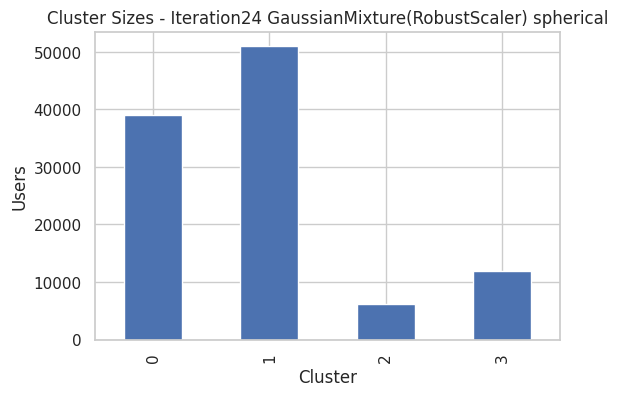

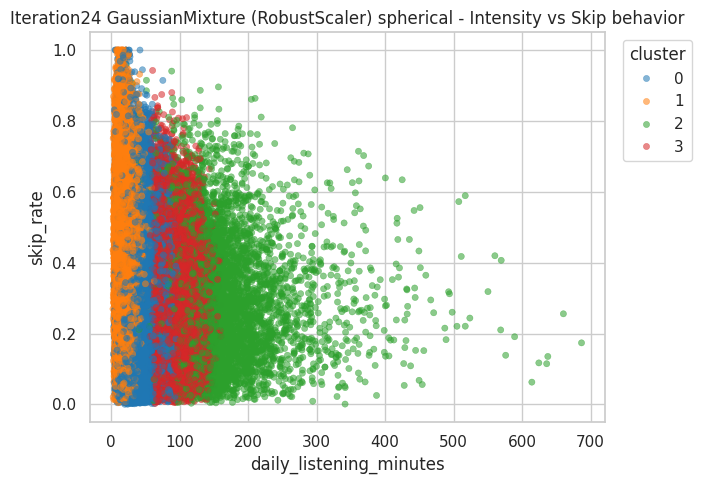

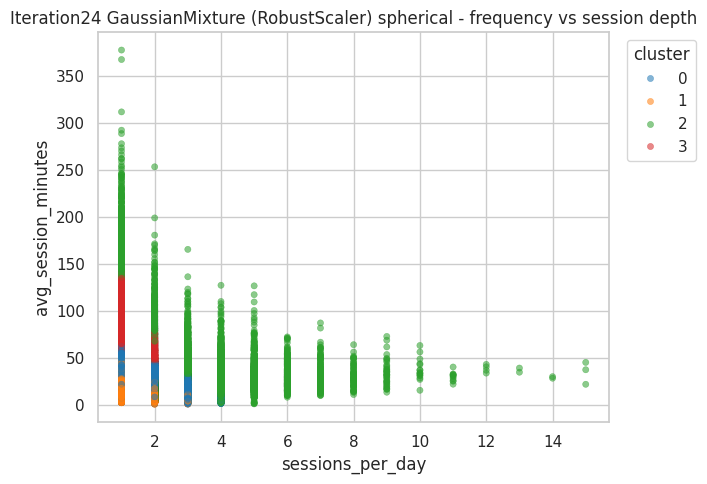

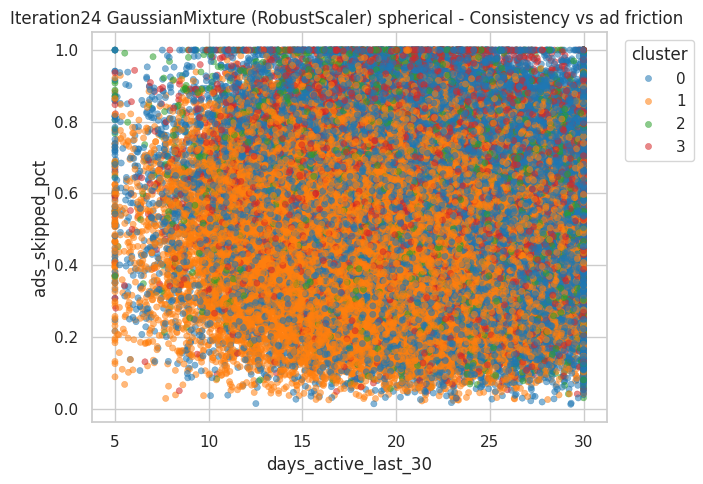

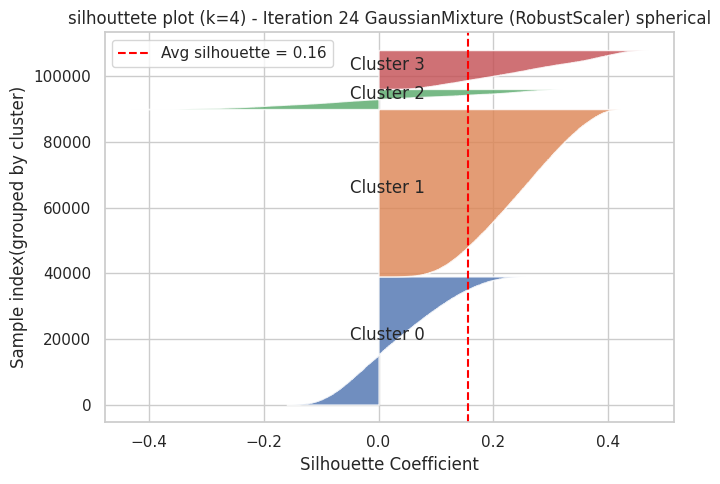

In [0]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score , silhouette_samples

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

spotify_user_behavior = spark.table(
    "spotify.spotify_user_behavior"
).toPandas()

CLUSTER_FEATURES_V1 = [
    "daily_listening_minutes",
    "sessions_per_day",
    "days_active_last_30",
    "avg_session_minutes",
    "skip_rate",
    "liked_songs_pct",
    "ads_skipped_pct",
]

base = spotify_user_behavior[["user_id"] + CLUSTER_FEATURES_V1].copy()

K = 4

X24 = base[CLUSTER_FEATURES_V1].copy()
Robust = RobustScaler()
X24_Robust = Robust.fit_transform(X24)

X24 = pd.DataFrame(
    X24_Robust,
    columns=CLUSTER_FEATURES_V1,
    index=base.index
)

gmm24 = GaussianMixture(
    n_components=K,
    random_state=42,
    covariance_type="spherical",
    n_init=5,
    max_iter=200
)

labels24 = gmm24.fit_predict(X24)

log_likelihood24 = gmm24.score(X24) * len(X24)
sil_avg_24 = silhouette_score(X24, labels24)

base_iter24 = base.copy()
base_iter24["cluster"] = labels24

print("iteration 24 results |k={K}")
print("Log Likelihood:", round(log_likelihood24, 2))
print("silhoutte:", round(sil_avg_24, 3))

sizes24 = base_iter24["cluster"].value_counts().sort_index()
means24 = (
    base_iter24
    .groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)

profile24 = means24.copy()
profile24.insert(0, "cluster_size", sizes24)

print("cluster profile(means,original scale) - Iteration 24 GaussianMixture(RobustScaler) spherical, labels):")
display(profile24)

plt.figure(figsize=(6,4))
base_iter24["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration24 GaussianMixture(RobustScaler) spherical")
plt.xlabel("Cluster")
plt.ylabel("Users")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter24,
    x="daily_listening_minutes",
    y="skip_rate",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration24 GaussianMixture (RobustScaler) spherical - Intensity vs Skip behavior")
plt.legend(title="cluster", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter24,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration24 GaussianMixture (RobustScaler) spherical - frequency vs session depth")
plt.legend(title="cluster", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter24,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration24 GaussianMixture (RobustScaler) spherical - Consistency vs ad friction ")
plt.legend(title="cluster", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

sil_values_24 = silhouette_samples(X24, labels24)

plt.figure(figsize=(7,5))
y_lower = 0

vals0 = sil_values_24[labels24 == 0]
vals0.sort()
size0 = vals0.shape[0]
y_upper = y_lower + size0
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals0, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size0, "Cluster 0")
y_lower = y_upper

vals1 = sil_values_24[labels24 == 1]
vals1.sort()
size1 = vals1.shape[0]
y_upper = y_lower + size1
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals1, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size1, "Cluster 1")
y_lower = y_upper

vals2 = sil_values_24[labels24 == 2]
vals2.sort()
size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size2, "Cluster 2")
y_lower = y_upper

vals3 = sil_values_24[labels24 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size3, "Cluster 3")
y_lower = y_upper

plt.axvline(
    x=sil_avg_24,
    color="red",
    linestyle="--",
    label=f"Avg silhouette = {sil_avg_24:.2f}"
)

plt.title("silhouttete plot (k=4) - Iteration 24 GaussianMixture (RobustScaler) spherical")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample index(grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()
